# Week 6 Shootout Main Notebook

This notebook uses the outputs from `prework_prepare_rainfall_data.ipynb`.

## Workflow
1. Read prework outputs
2. Inspect time summaries and choose one `obsTime` for each event
3. Build event GeoDataFrames in EPSG:3826
4. Run four interpolation methods:
   - Nearest Neighbor
   - IDW
   - Ordinary Kriging
   - Random Forest
5. Compare maps
6. Create sigma maps
7. Export GeoTIFF for one event


## 0. Packages


In [1]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from scipy.interpolate import NearestNDInterpolator
from scipy.spatial.distance import cdist

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

from pykrige.ok import OrdinaryKriging

import rasterio
from rasterio.transform import from_origin

warnings.filterwarnings("ignore")
print("✅ Packages imported")


✅ Packages imported


## 1. User Settings

This notebook expects the outputs from the prework notebook.


In [2]:
# ===== User settings =====
PREWORK_DIR = Path("prework_outputs")
OUTPUT_DIR = Path("week6_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CRS_WGS84 = "EPSG:4326"
CRS_TWD97 = "EPSG:3826"
GRID_RES = 1000

# Event folders from prework outputs
EVENT1_DATE = "20220912"   # Muifa candidate
EVENT2_DATE = "20221029"   # 1029 heavy rainfall candidate

EVENT1_NAME = "Muifa"
EVENT2_NAME = "1029 Heavy Rain"

# Choose one rainfall column for the spatial interpolation
RAIN_COL = "RAIN"

# Random Forest parameters
RF_N_ESTIMATORS = 200
RF_MIN_SAMPLES_LEAF = 3

print("PREWORK_DIR =", PREWORK_DIR.resolve())
print("OUTPUT_DIR =", OUTPUT_DIR.resolve())


PREWORK_DIR = D:\Class_satellite\HW7\prework_outputs
OUTPUT_DIR = D:\Class_satellite\HW7\week6_outputs


## 2. Read Prepared Files


In [3]:
def read_prework_valid_csv(prework_dir, date_str):
    path = prework_dir / date_str / f"rain_{date_str}_yl_hl_valid.csv"
    if not path.exists():
        raise FileNotFoundError(f"Missing prepared file: {path}")
    df = pd.read_csv(path, encoding="utf-8")
    if "obsTime" in df.columns:
        df["obsTime"] = pd.to_datetime(df["obsTime"], errors="coerce")
    return df, path

event1_all, event1_path = read_prework_valid_csv(PREWORK_DIR, EVENT1_DATE)
event2_all, event2_path = read_prework_valid_csv(PREWORK_DIR, EVENT2_DATE)

print("Event 1 file:", event1_path)
print("Event 2 file:", event2_path)
print("Event 1 shape:", event1_all.shape)
print("Event 2 shape:", event2_all.shape)

display(event1_all.head())
display(event2_all.head())


Event 1 file: prework_outputs\20220912\rain_20220912_yl_hl_valid.csv
Event 2 file: prework_outputs\20221029\rain_20221029_yl_hl_valid.csv
Event 1 shape: (5625, 15)
Event 2 shape: (10517, 15)


,station_id,obsTime,ELEV,RAIN,MIN_10,HOUR_3,HOUR_6,HOUR_12,HOUR_24,NOW,station_name,county,town,lat,lon
0,01U070,2022-09-12,585.0,6.0,0.0,17.0,45.0,80.0,100.0,100.0,留茂安,宜蘭縣,大同鄉,24.531772,121.451236
1,C0T9A0,2022-09-12,498.0,1.0,0.0,1.0,1.0,1.0,3.0,3.0,月眉山,花蓮縣,壽豐鄉,23.809928,121.539828
2,88U940,2022-09-12,175.0,1.0,0.0,30.5,34.0,56.5,93.0,93.0,寒溪,宜蘭縣,大同鄉,24.609167,121.686944
3,C0U710,2022-09-12,1942.0,14.5,0.0,40.5,73.0,119.0,158.0,158.0,太平山,宜蘭縣,大同鄉,24.505486,121.525656
4,C0Z190,2022-09-12,62.0,1.0,0.0,4.5,4.5,4.5,9.0,9.0,富世,花蓮縣,秀林鄉,24.147433,121.629703


,station_id,obsTime,ELEV,RAIN,MIN_10,HOUR_3,HOUR_6,HOUR_12,HOUR_24,NOW,station_name,county,town,lat,lon
0,C0U910,2022-10-29,17.0,3.5,0.5,19.5,21.0,38.5,43.5,43.5,冬山,宜蘭縣,冬山鄉,24.633725,121.793697
1,01U790,2022-10-29,268.0,10.0,0.0,15.0,20.0,30.0,37.0,37.0,清水,宜蘭縣,大同鄉,24.614906,121.637272
2,01U560,2022-10-29,1960.0,1.0,0.0,3.0,8.0,11.0,15.0,15.0,太平山(1),宜蘭縣,大同鄉,24.494522,121.536435
3,C1U930,2022-10-29,5.0,6.5,1.5,39.5,49.5,67.0,86.0,86.0,粉鳥林,宜蘭縣,蘇澳鎮,24.497089,121.842481
4,C0UA10,2022-10-29,1711.0,0.5,0.5,3.0,8.5,12.0,16.0,16.0,鴛鴦湖,宜蘭縣,大同鄉,24.590269,121.412228


## 3. Time Summary for Each Event

Use this to choose one representative `obsTime` per event.


In [4]:
def build_time_summary(df, rain_col="RAIN"):
    out = (
        df.groupby("obsTime")
        .agg(
            n_rows=("station_id", "count"),
            n_station=("station_id", "nunique"),
            rain_mean=(rain_col, "mean"),
            rain_max=(rain_col, "max"),
            rain_std=(rain_col, "std"),
        )
        .reset_index()
        .sort_values("rain_max", ascending=False)
    )
    return out

event1_time_summary = build_time_summary(event1_all, RAIN_COL)
event2_time_summary = build_time_summary(event2_all, RAIN_COL)

display(event1_time_summary.head(20))
display(event2_time_summary.head(20))


,obsTime,n_rows,n_station,rain_mean,rain_max,rain_std
105,2022-09-12 17:50:00,59,59,9.389831,42.5,9.510007
104,2022-09-12 17:40:00,64,64,8.203125,42.0,8.564748
106,2022-09-12 18:00:00,57,57,9.614035,34.5,9.343169
103,2022-09-12 17:30:00,64,64,7.054688,34.5,7.198499
107,2022-09-12 18:10:00,58,58,8.750000,32.0,8.545159
83,2022-09-12 14:10:00,52,52,4.894231,27.5,5.330578
84,2022-09-12 14:20:00,52,52,5.182692,27.0,5.437730
102,2022-09-12 17:20:00,61,61,6.139344,26.5,5.921804
85,2022-09-12 14:30:00,56,56,4.982143,25.0,4.948796
86,2022-09-12 14:40:00,53,53,5.660377,24.5,4.585485


,obsTime,n_rows,n_station,rain_mean,rain_max,rain_std
30,2022-10-29 05:00:00,89,89,4.303371,40.0,5.351093
56,2022-10-29 09:20:00,57,57,2.394737,39.5,5.481085
31,2022-10-29 05:10:00,91,91,4.329670,37.0,5.005119
57,2022-10-29 09:30:00,51,51,2.431373,35.5,5.252637
33,2022-10-29 05:30:00,92,92,4.086957,34.5,4.564320
29,2022-10-29 04:50:00,91,91,4.082418,34.5,4.989580
55,2022-10-29 09:10:00,61,61,2.180328,33.5,4.578967
108,2022-10-29 18:40:00,105,105,4.152381,33.5,3.998872
34,2022-10-29 05:40:00,93,93,3.854839,33.0,4.318552
109,2022-10-29 18:50:00,108,108,3.837963,32.0,3.749660


## 4. Choose One `obsTime` per Event

After checking the summary tables above, set the final times here.


In [5]:
# ===== Set your final event times here after checking the summary tables =====
# Example placeholders:
EVENT1_OBSTIME = event1_time_summary.iloc[0]["obsTime"]
EVENT2_OBSTIME = event2_time_summary.iloc[0]["obsTime"]

print("EVENT1_OBSTIME =", EVENT1_OBSTIME)
print("EVENT2_OBSTIME =", EVENT2_OBSTIME)


EVENT1_OBSTIME = 2022-09-12 17:50:00
EVENT2_OBSTIME = 2022-10-29 05:00:00


## 5. Build Final Event DataFrames


In [6]:
def select_event_snapshot(df, obs_time):
    out = df[df["obsTime"] == obs_time].copy()
    out = out.dropna(subset=["lat", "lon", RAIN_COL])
    out = out.drop_duplicates(subset=["station_id"])
    return out

event1 = select_event_snapshot(event1_all, EVENT1_OBSTIME)
event2 = select_event_snapshot(event2_all, EVENT2_OBSTIME)

print("Event 1 snapshot shape:", event1.shape)
print("Event 2 snapshot shape:", event2.shape)

display(event1.head())
display(event2.head())


Event 1 snapshot shape: (59, 15)
Event 2 snapshot shape: (89, 15)


,station_id,obsTime,ELEV,RAIN,MIN_10,HOUR_3,HOUR_6,HOUR_12,HOUR_24,NOW,station_name,county,town,lat,lon
3934,88U940,2022-09-12 17:50:00,175.0,9.0,0.5,16.0,21.5,29.0,64.0,30.0,寒溪,宜蘭縣,大同鄉,24.609167,121.686944
3935,01U460,2022-09-12 17:50:00,83.0,19.0,0.0,25.0,40.0,60.0,92.0,62.0,五峰,宜蘭縣,礁溪鄉,24.829997,121.748477
3936,01U470,2022-09-12 17:50:00,32.0,8.0,0.0,11.0,14.0,17.0,26.0,18.0,武塔,宜蘭縣,南澳鄉,24.449458,121.777220
3937,B2U990,2022-09-12 17:50:00,10.0,11.0,0.0,13.0,16.5,20.0,46.0,20.5,畜試東區分所,宜蘭縣,五結鄉,24.669039,121.832561
3938,C0U900,2022-09-12 17:50:00,63.0,22.0,2.0,25.5,27.0,31.0,64.0,35.5,內城,宜蘭縣,員山鄉,24.718133,121.687664


,station_id,obsTime,ELEV,RAIN,MIN_10,HOUR_3,HOUR_6,HOUR_12,HOUR_24,NOW,station_name,county,town,lat,lon
1975,O1T840,2022-10-29 05:00:00,18.0,4.0,0.0,22.0,24.0,24.0,24.0,24.0,花蓮,花蓮縣,花蓮市,23.972934,121.605986
1976,01U070,2022-10-29 05:00:00,585.0,1.0,0.0,1.0,1.0,2.0,3.0,1.0,留茂安,宜蘭縣,大同鄉,24.531772,121.451236
1977,C0T9A0,2022-10-29 05:00:00,498.0,7.0,1.0,18.0,21.0,21.0,21.0,21.0,月眉山,花蓮縣,壽豐鄉,23.809928,121.539828
1978,01U470,2022-10-29 05:00:00,32.0,1.0,0.0,3.0,15.0,29.0,37.0,9.0,武塔,宜蘭縣,南澳鄉,24.449458,121.777220
1979,C0U710,2022-10-29 05:00:00,1942.0,1.5,0.5,3.0,4.0,7.5,14.5,4.0,太平山,宜蘭縣,大同鄉,24.505486,121.525656


## 6. Convert to GeoDataFrame (EPSG:3826)


In [7]:
def to_gdf_3826(df):
    gdf = gpd.GeoDataFrame(
        df.copy(),
        geometry=gpd.points_from_xy(df["lon"], df["lat"]),
        crs=CRS_WGS84
    ).to_crs(CRS_TWD97)

    gdf["easting"] = gdf.geometry.x
    gdf["northing"] = gdf.geometry.y
    return gdf

event1_gdf = to_gdf_3826(event1)
event2_gdf = to_gdf_3826(event2)

print(event1_gdf.shape, event2_gdf.shape)
display(event1_gdf[["station_id", "station_name", "county", "easting", "northing", RAIN_COL]].head())
display(event2_gdf[["station_id", "station_name", "county", "easting", "northing", RAIN_COL]].head())


(59, 18) (89, 18)


,station_id,station_name,county,easting,northing,RAIN
3934,88U940,寒溪,宜蘭縣,319558.953824,2.722663e+06,9.0
3935,01U460,五峰,宜蘭縣,325656.291796,2.747155e+06,19.0
3936,01U470,武塔,宜蘭縣,328800.146021,2.705022e+06,8.0
3937,B2U990,畜試東區分所,宜蘭縣,334264.365861,2.729376e+06,11.0
3938,C0U900,內城,宜蘭縣,319571.412410,2.734733e+06,22.0


,station_id,station_name,county,easting,northing,RAIN
1975,O1T840,花蓮,花蓮縣,311667.648374,2.652158e+06,4.0
1976,01U070,留茂安,宜蘭縣,295719.166060,2.713992e+06,1.0
1977,C0T9A0,月眉山,花蓮縣,305003.882175,2.634078e+06,7.0
1978,01U470,武塔,宜蘭縣,328800.146021,2.705022e+06,1.0
1979,C0U710,太平山,宜蘭縣,303270.604146,2.711107e+06,1.5


## 7. Quick Distribution Check


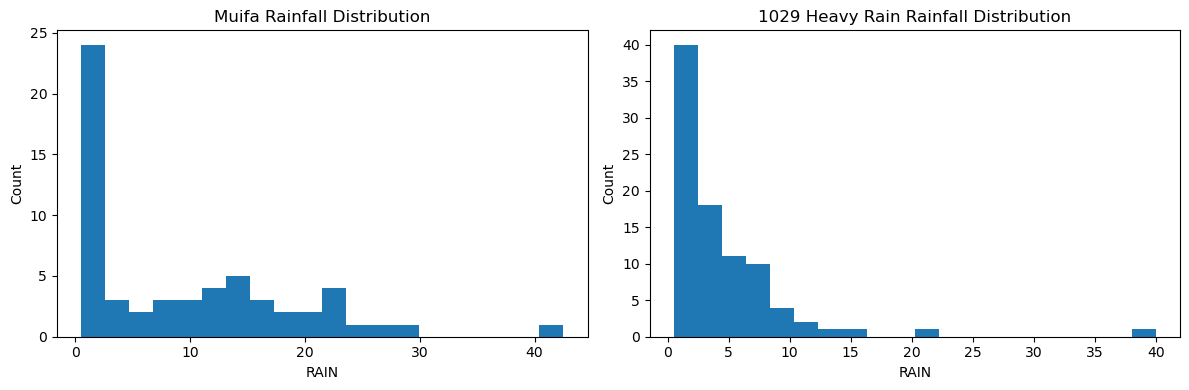

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(event1_gdf[RAIN_COL], bins=20)
axes[0].set_title(f"{EVENT1_NAME} Rainfall Distribution")
axes[0].set_xlabel(RAIN_COL)
axes[0].set_ylabel("Count")

axes[1].hist(event2_gdf[RAIN_COL], bins=20)
axes[1].set_title(f"{EVENT2_NAME} Rainfall Distribution")
axes[1].set_xlabel(RAIN_COL)
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 8. Build Prediction Grid


In [9]:
def build_prediction_grid(gdf, grid_res=1000, padding=2000):
    minx, miny, maxx, maxy = gdf.total_bounds

    minx -= padding
    miny -= padding
    maxx += padding
    maxy += padding

    xs = np.arange(minx, maxx + grid_res, grid_res)
    ys = np.arange(miny, maxy + grid_res, grid_res)

    xx, yy = np.meshgrid(xs, ys)

    grid_df = pd.DataFrame({
        "easting": xx.ravel(),
        "northing": yy.ravel()
    })

    return xs, ys, xx, yy, grid_df

xs1, ys1, xx1, yy1, grid1 = build_prediction_grid(event1_gdf, grid_res=GRID_RES)
xs2, ys2, xx2, yy2, grid2 = build_prediction_grid(event2_gdf, grid_res=GRID_RES)

print("Event 1 grid shape:", yy1.shape)
print("Event 2 grid shape:", yy2.shape)


Event 1 grid shape: (115, 63)
Event 2 grid shape: (178, 70)


## 9. Interpolation Functions


In [10]:
def predict_nearest(gdf, grid_df, rain_col="RAIN"):
    points = gdf[["easting", "northing"]].values
    values = gdf[rain_col].values
    model = NearestNDInterpolator(points, values)
    pred = model(grid_df["easting"].values, grid_df["northing"].values)
    return pred

def predict_idw(gdf, grid_df, rain_col="RAIN", power=2):
    station_xy = gdf[["easting", "northing"]].values
    station_val = gdf[rain_col].values
    grid_xy = grid_df[["easting", "northing"]].values

    dists = cdist(grid_xy, station_xy, metric="euclidean")
    dists[dists == 0] = 1e-12

    weights = 1 / (dists ** power)
    pred = (weights @ station_val) / weights.sum(axis=1)
    return pred

def fit_kriging(gdf, rain_col="RAIN", variogram_model="spherical"):
    x = gdf["easting"].values
    y = gdf["northing"].values
    z = gdf[rain_col].values

    ok = OrdinaryKriging(
        x, y, z,
        variogram_model=variogram_model,
        verbose=False,
        enable_plotting=False
    )
    return ok

def predict_kriging(ok_model, xs, ys):
    zhat, ss = ok_model.execute("grid", xs, ys)
    return np.array(zhat), np.array(ss)

def predict_rf(gdf, grid_df, rain_col="RAIN", n_estimators=200, min_samples_leaf=3, random_state=42):
    X = gdf[["easting", "northing"]].values
    y = gdf[rain_col].values

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        min_samples_leaf=min_samples_leaf,
        random_state=random_state,
        n_jobs=-1
    )
    rf.fit(X, y)

    pred = rf.predict(grid_df[["easting", "northing"]].values)
    return rf, pred


## 10. Variogram Candidates

Compare at least two models for each event.


In [11]:
def summarize_kriging_model(ok_model, model_name):
    return {
        "model": model_name,
        "variogram_model": getattr(ok_model, "variogram_model", None),
        "variogram_parameters": getattr(ok_model, "variogram_model_parameters", None)
    }

ok1_sph = fit_kriging(event1_gdf, rain_col=RAIN_COL, variogram_model="spherical")
ok1_exp = fit_kriging(event1_gdf, rain_col=RAIN_COL, variogram_model="exponential")

ok2_sph = fit_kriging(event2_gdf, rain_col=RAIN_COL, variogram_model="spherical")
ok2_exp = fit_kriging(event2_gdf, rain_col=RAIN_COL, variogram_model="exponential")

event1_variogram_summary = pd.DataFrame([
    summarize_kriging_model(ok1_sph, "spherical"),
    summarize_kriging_model(ok1_exp, "exponential"),
])

event2_variogram_summary = pd.DataFrame([
    summarize_kriging_model(ok2_sph, "spherical"),
    summarize_kriging_model(ok2_exp, "exponential"),
])

display(event1_variogram_summary)
display(event2_variogram_summary)


,model,variogram_model,variogram_parameters
0,spherical,spherical,"[96.58514247410797, 28997.205053616548, 5.4595..."
1,exponential,exponential,"[101.80175829414483, 37953.39299236477, 8.6316..."


,model,variogram_model,variogram_parameters
0,spherical,spherical,"[16.601881025238843, 153250.4243968796, 21.207..."
1,exponential,exponential,"[17.564978647734407, 156855.03708100083, 20.54..."


## 11. Select Best Variogram Model


In [12]:
# ===== Change these if needed after checking summaries =====
BEST_MODEL_EVENT1 = "spherical"
BEST_MODEL_EVENT2 = "exponential"

print("BEST_MODEL_EVENT1 =", BEST_MODEL_EVENT1)
print("BEST_MODEL_EVENT2 =", BEST_MODEL_EVENT2)


BEST_MODEL_EVENT1 = spherical
BEST_MODEL_EVENT2 = exponential


## 12. Run Four Methods for Event 1


In [13]:
nearest1 = predict_nearest(event1_gdf, grid1, rain_col=RAIN_COL).reshape(yy1.shape)
idw1 = predict_idw(event1_gdf, grid1, rain_col=RAIN_COL, power=2).reshape(yy1.shape)

ok1_best = fit_kriging(event1_gdf, rain_col=RAIN_COL, variogram_model=BEST_MODEL_EVENT1)
krig1, sigma1 = predict_kriging(ok1_best, xs1, ys1)

rf_model1, rf1_flat = predict_rf(
    event1_gdf, grid1,
    rain_col=RAIN_COL,
    n_estimators=RF_N_ESTIMATORS,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF
)
rf1 = rf1_flat.reshape(yy1.shape)

print("✅ Event 1 finished")


✅ Event 1 finished


## 13. Run Four Methods for Event 2


In [14]:
nearest2 = predict_nearest(event2_gdf, grid2, rain_col=RAIN_COL).reshape(yy2.shape)
idw2 = predict_idw(event2_gdf, grid2, rain_col=RAIN_COL, power=2).reshape(yy2.shape)

ok2_best = fit_kriging(event2_gdf, rain_col=RAIN_COL, variogram_model=BEST_MODEL_EVENT2)
krig2, sigma2 = predict_kriging(ok2_best, xs2, ys2)

rf_model2, rf2_flat = predict_rf(
    event2_gdf, grid2,
    rain_col=RAIN_COL,
    n_estimators=RF_N_ESTIMATORS,
    min_samples_leaf=RF_MIN_SAMPLES_LEAF
)
rf2 = rf2_flat.reshape(yy2.shape)

print("✅ Event 2 finished")


✅ Event 2 finished


## 14. 2×2 Comparison Plot


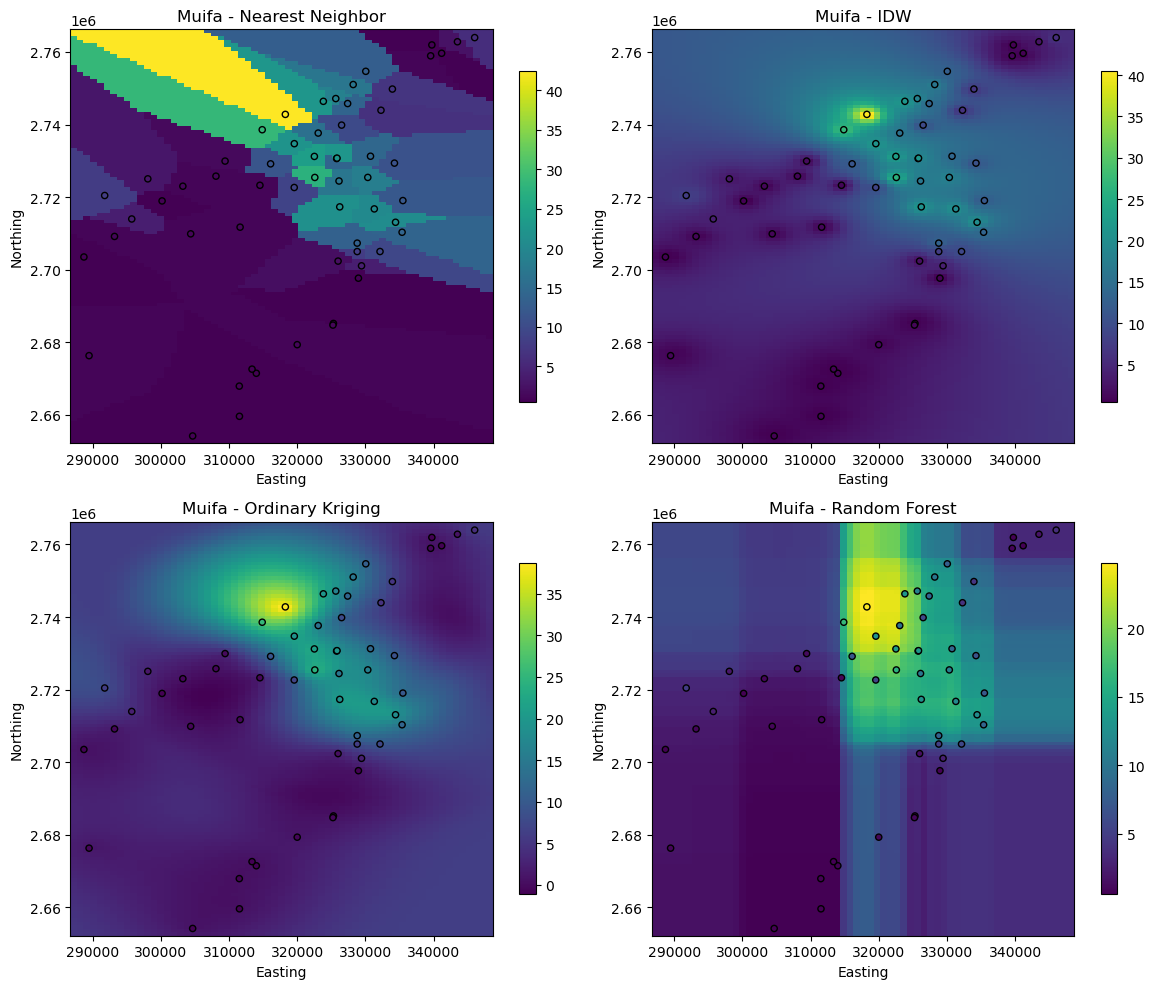

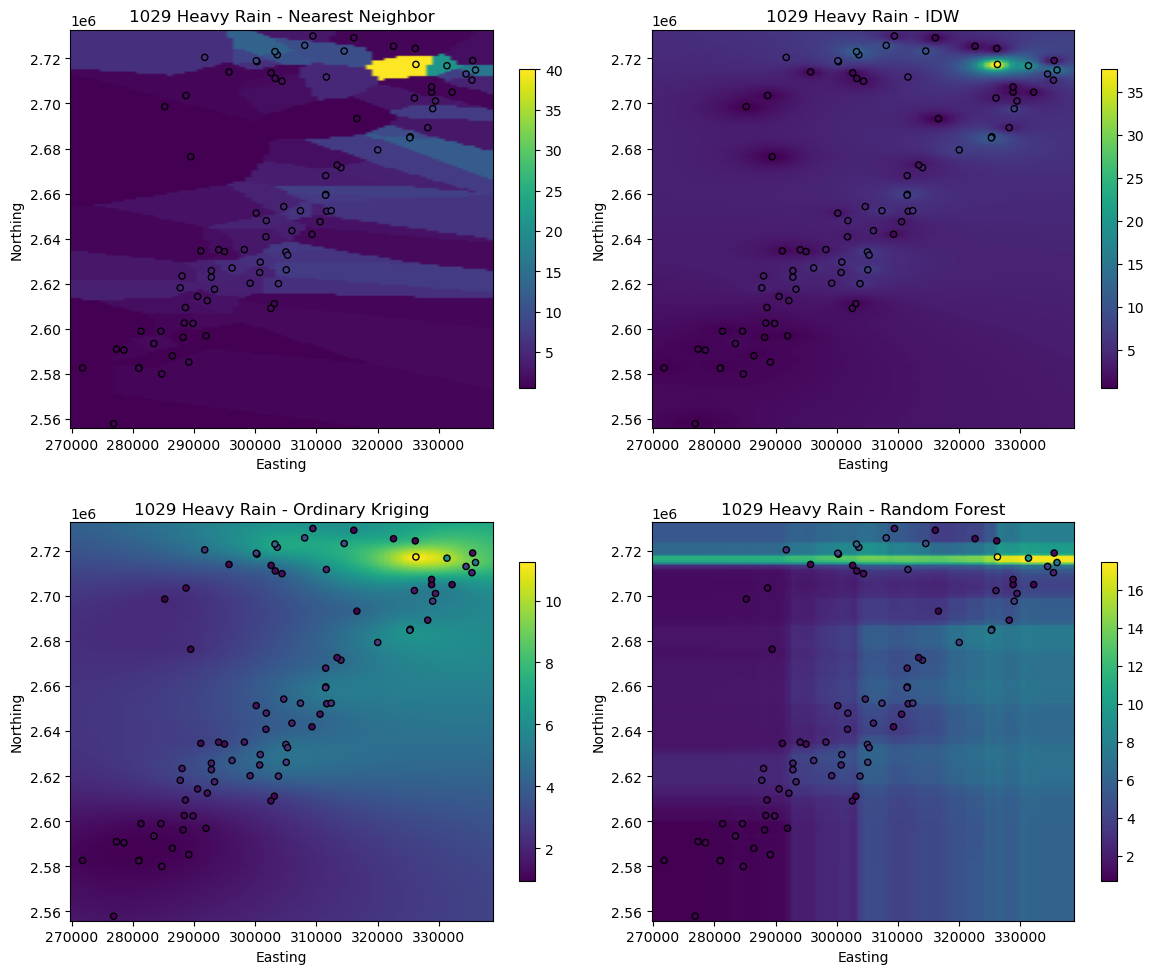

In [15]:
def plot_four_methods(gdf, xs, ys, nearest_grid, idw_grid, krig_grid, rf_grid, title_prefix, rain_col="RAIN"):
    extent = [xs.min(), xs.max(), ys.min(), ys.max()]
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    plots = [
        (nearest_grid, "Nearest Neighbor"),
        (idw_grid, "IDW"),
        (krig_grid, "Ordinary Kriging"),
        (rf_grid, "Random Forest"),
    ]

    for ax, (grid, title) in zip(axes.ravel(), plots):
        im = ax.imshow(grid, origin="lower", extent=extent, aspect="auto")
        ax.scatter(gdf["easting"], gdf["northing"], c=gdf[rain_col], s=20, edgecolor="k")
        ax.set_title(f"{title_prefix} - {title}")
        ax.set_xlabel("Easting")
        ax.set_ylabel("Northing")
        plt.colorbar(im, ax=ax, shrink=0.8)

    plt.tight_layout()
    plt.show()

plot_four_methods(event1_gdf, xs1, ys1, nearest1, idw1, krig1, rf1, EVENT1_NAME, rain_col=RAIN_COL)
plot_four_methods(event2_gdf, xs2, ys2, nearest2, idw2, krig2, rf2, EVENT2_NAME, rain_col=RAIN_COL)


## 15. Kriging vs RF Difference Maps


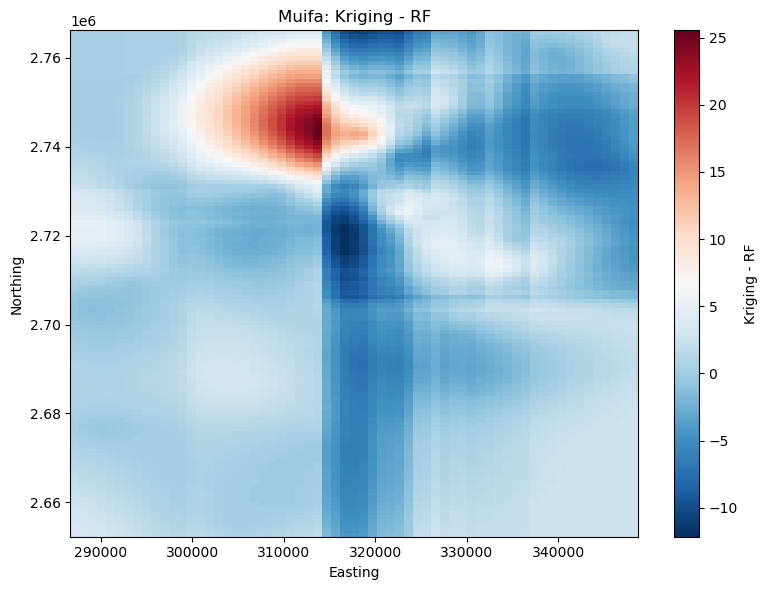

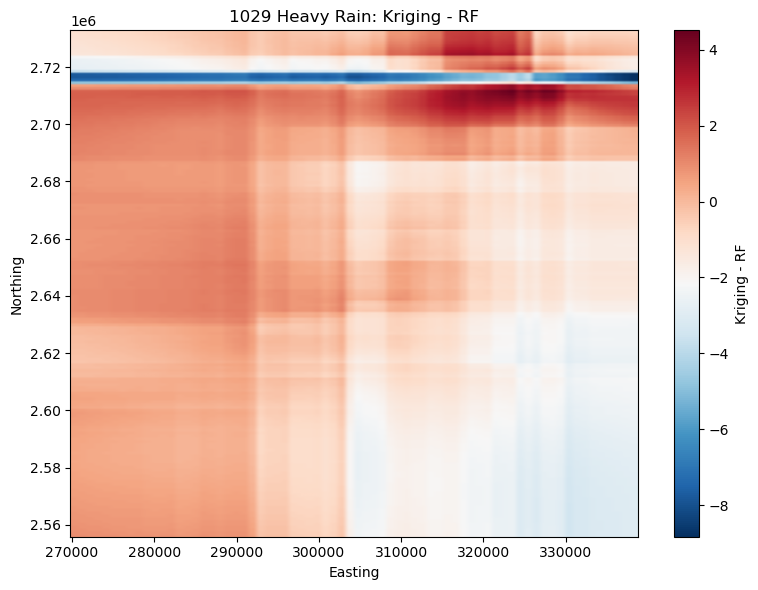

In [16]:
def plot_difference_map(xs, ys, diff_grid, title):
    extent = [xs.min(), xs.max(), ys.min(), ys.max()]
    plt.figure(figsize=(8, 6))
    plt.imshow(diff_grid, origin="lower", extent=extent, aspect="auto", cmap="RdBu_r")
    plt.colorbar(label="Kriging - RF")
    plt.title(title)
    plt.xlabel("Easting")
    plt.ylabel("Northing")
    plt.tight_layout()
    plt.show()

diff1 = krig1 - rf1
diff2 = krig2 - rf2

plot_difference_map(xs1, ys1, diff1, f"{EVENT1_NAME}: Kriging - RF")
plot_difference_map(xs2, ys2, diff2, f"{EVENT2_NAME}: Kriging - RF")


## 16. Sigma Maps


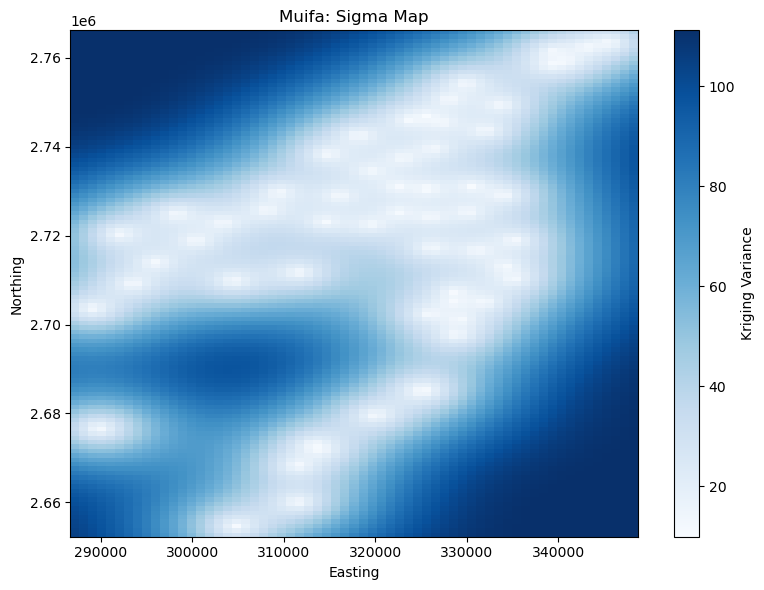

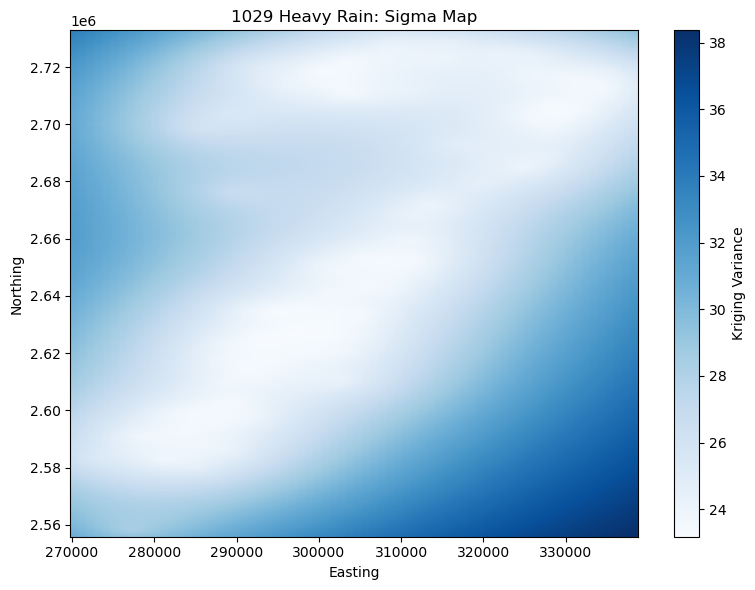

In [17]:
def plot_sigma_map(xs, ys, sigma_grid, title):
    extent = [xs.min(), xs.max(), ys.min(), ys.max()]
    plt.figure(figsize=(8, 6))
    plt.imshow(sigma_grid, origin="lower", extent=extent, aspect="auto", cmap="Blues")
    plt.colorbar(label="Kriging Variance")
    plt.title(title)
    plt.xlabel("Easting")
    plt.ylabel("Northing")
    plt.tight_layout()
    plt.show()

plot_sigma_map(xs1, ys1, sigma1, f"{EVENT1_NAME}: Sigma Map")
plot_sigma_map(xs2, ys2, sigma2, f"{EVENT2_NAME}: Sigma Map")


## 17. Optional RF Cross-Validation


In [18]:
def evaluate_rf_cv(gdf, rain_col="RAIN", n_estimators=200, min_samples_leaf=3):
    X = gdf[["easting", "northing"]].values
    y = gdf[rain_col].values

    rf = RandomForestRegressor(
        n_estimators=n_estimators,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    cv = KFold(n_splits=min(5, len(gdf)), shuffle=True, random_state=42)
    scores = cross_val_score(rf, X, y, cv=cv, scoring="neg_root_mean_squared_error")
    return -scores

rf_cv_1 = evaluate_rf_cv(event1_gdf, rain_col=RAIN_COL, n_estimators=RF_N_ESTIMATORS, min_samples_leaf=RF_MIN_SAMPLES_LEAF)
rf_cv_2 = evaluate_rf_cv(event2_gdf, rain_col=RAIN_COL, n_estimators=RF_N_ESTIMATORS, min_samples_leaf=RF_MIN_SAMPLES_LEAF)

print(EVENT1_NAME, "RF RMSE:", rf_cv_1, "Mean =", rf_cv_1.mean())
print(EVENT2_NAME, "RF RMSE:", rf_cv_2, "Mean =", rf_cv_2.mean())


Muifa RF RMSE: [4.33651454 6.66839063 8.28964518 6.98232808 5.49289003] Mean = 6.353953693537626
1029 Heavy Rain RF RMSE: [4.12010145 4.3277337  2.18597481 2.74203227 7.58432944] Mean = 4.1920343363316395


## 18. Variogram Comparison Table


In [19]:
variogram_compare = pd.DataFrame({
    "Parameter": ["Sill", "Range", "Nugget", "Best Model", "Interpretation"],
    EVENT1_NAME: ["", "", "", BEST_MODEL_EVENT1, ""],
    EVENT2_NAME: ["", "", "", BEST_MODEL_EVENT2, ""],
    "Difference Reason": ["", "", "", "", ""]
})

display(variogram_compare)


,Parameter,Muifa,1029 Heavy Rain,Difference Reason
0,Sill,,,
1,Range,,,
2,Nugget,,,
3,Best Model,spherical,exponential,
4,Interpretation,,,


## 19. GeoTIFF Export

The assignment only requires one event for GeoTIFF export.


In [20]:
def export_geotiff(array2d, xs, ys, out_path, crs="EPSG:3826", nodata=np.nan):
    xres = xs[1] - xs[0]
    yres = ys[1] - ys[0]

    transform = from_origin(
        west=xs.min(),
        north=ys.max() + yres,
        xsize=xres,
        ysize=yres
    )

    arr = np.flipud(array2d).astype("float32")

    with rasterio.open(
        out_path,
        "w",
        driver="GTiff",
        height=arr.shape[0],
        width=arr.shape[1],
        count=1,
        dtype="float32",
        crs=crs,
        transform=transform,
        nodata=nodata
    ) as dst:
        dst.write(arr, 1)

    print(f"✅ Saved: {out_path}")


In [21]:
# Export Event 1 by default
export_geotiff(krig1, xs1, ys1, OUTPUT_DIR / "kriging_rainfall.tif")
export_geotiff(sigma1, xs1, ys1, OUTPUT_DIR / "kriging_variance.tif")
export_geotiff(rf1, xs1, ys1, OUTPUT_DIR / "rf_rainfall.tif")


✅ Saved: week6_outputs\kriging_rainfall.tif
✅ Saved: week6_outputs\kriging_variance.tif
✅ Saved: week6_outputs\rf_rainfall.tif


## 20. Writing Area

Use this section to draft your Part A interpretation.

### Variogram
- Why Event 1 best model:
- Why Event 2 best model:
- Sill difference:
- Range difference:
- Nugget difference:

### Sigma Map
- Differences between the two sigma maps:
- Which event has higher Kriging confidence:
- What should a commander do in high-variance areas:
- Can Random Forest provide similar uncertainty information:

### Method Comparison
- Nearest:
- IDW:
- Kriging:
- RF:
